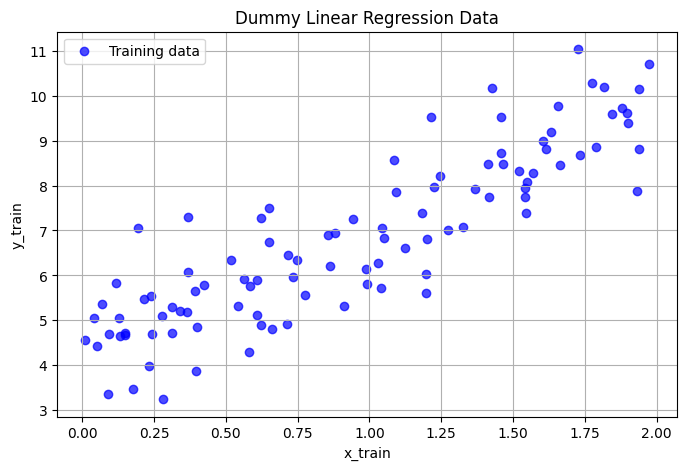

Features shape is: (100, 1)
Target shape is: (100, 1)


In [11]:
import numpy as np
import matplotlib.pyplot as plt


# Set the seed for reproducibility
np.random.seed(42)

# Number of samples

num_samples = 100

# Generate random x values (features)
x_train = 2 * np.random.rand(num_samples, 1)

# Generate corresponding y values with a linear relationship (y = 4 + 3x + noise)
true_slope = 3
true_intercept = 4
noise = np.random.randn(num_samples, 1)

y_train = true_intercept + true_slope * x_train + noise

# Plotting the data
plt.figure(figsize = (8, 5))
plt.scatter(x_train, y_train, color = "blue", label = "Training data", alpha = 0.7)
plt.title("Dummy Linear Regression Data")
plt.xlabel("x_train")
plt.ylabel("y_train")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape is:", x_train.shape)
print("Target shape is:", y_train.shape)

In [12]:
#finding Threshold

def get_best_split(x, y):
    best_variance=float('inf')
    best_threshold=None
    threshold = np.unique(x)
    for i in threshold:
        left = x<=i
        right= x>i
        y_left=y[left]
        y_right=y[right]
        #left_side Variance
        n_left=len(y_left)
        if n_left>0:
            mean_left= np.sum(y_left)/n_left #average
            var_left = np.sum((y_left-mean_left)**2)/n_left
        else:
            var_left=0
        #right_side Variance
        n_right=len(y_right)
        if n_right>0:
            mean_right = np.sum(y_right)/n_right
            var_right= np.sum((y_right-mean_right)**2)/n_right
        else:
            var_right=0
        total_var= (n_left*var_left+n_right*var_right)/(n_left+n_right)
        if total_var<best_variance:
            best_variance = total_var
            best_threshold=i
    return best_variance, best_threshold

In [13]:
def build_tree(x, y, depth, max_depth):
    if depth>= max_depth or len(y)<=1 :
        return np.mean(y)
    best_variance,best_threshold=get_best_split(x,y)
    if best_threshold is None :
        return np.mean(y)
    left =x<=best_threshold
    right=x>best_threshold
    left_child = build_tree(x[left],y[left],depth+1,max_depth)
    right_child= build_tree(x[right],y[right], depth+1, max_depth)
    return {
        "threshold": best_threshold,
        "left": left_child,
        "right": right_child
        }

In [14]:
build_tree(x_train,y_train,0,3)

{'threshold': np.float64(1.2022300234864176),
 'left': {'threshold': np.float64(0.6219646434313244),
  'left': {'threshold': np.float64(0.31203728088487304),
   'left': np.float64(4.802807983131931),
   'right': np.float64(5.464096241542939)},
  'right': {'threshold': np.float64(1.0401360423556216),
   'left': np.float64(6.226334784339506),
   'right': np.float64(6.9730059284087655)}},
 'right': {'threshold': np.float64(1.5703519227860272),
  'left': {'threshold': np.float64(1.2150897038028767),
   'left': np.float64(9.53145501261916),
   'right': np.float64(8.181998021462965)},
  'right': {'threshold': np.float64(1.9391692555291171),
   'left': np.float64(9.338002933402544),
   'right': np.float64(10.425677357006032)}}}

In [15]:
def predict_single (node,x_val):
    if not isinstance(node,dict):
        return node
    if x_val <= node['threshold']:
        return predict_single(node['left'],x_val)
    else:
        return predict_single(node['right'],x_val)

In [16]:
def predict(tree,X):
    return np.array([predict_single(tree,x_val)for x_val in X])

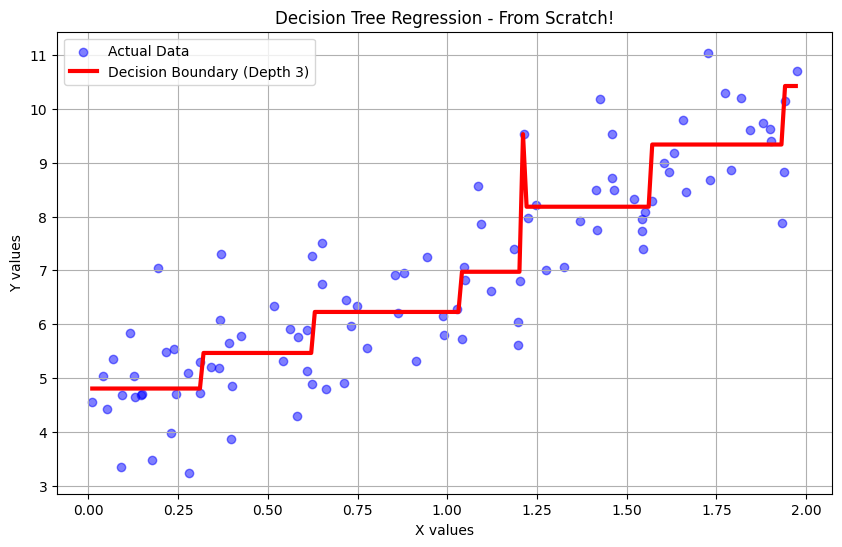

In [17]:
# 1. Pehle apne tree ko ek variable mein save kar lo
my_tree = build_tree(x_train, y_train, 0, 3)

# 2. Smooth line banane ke liye x ki bohot saari pass-pass values generate karte hain
# YAHAN CHANGE KIYA: min() aur max() ko x_train.min() aur x_train.max() kar diya
x_plot = np.arange(x_train.min(), x_train.max(), 0.01).reshape(-1, 1)

# 3. In naye points par apne tree se prediction nikalte hain
y_plot = predict(my_tree, x_plot)

# 4. Graph Plotting
plt.figure(figsize=(10, 6))

# Original data points (Blue dots)
plt.scatter(x_train, y_train, color='blue', label='Actual Data', alpha=0.5)

# Decision boundary line (Red steps)
plt.plot(x_plot, y_plot, color='red', linewidth=3, label='Decision Boundary (Depth 3)')

plt.title("Decision Tree Regression - From Scratch!")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

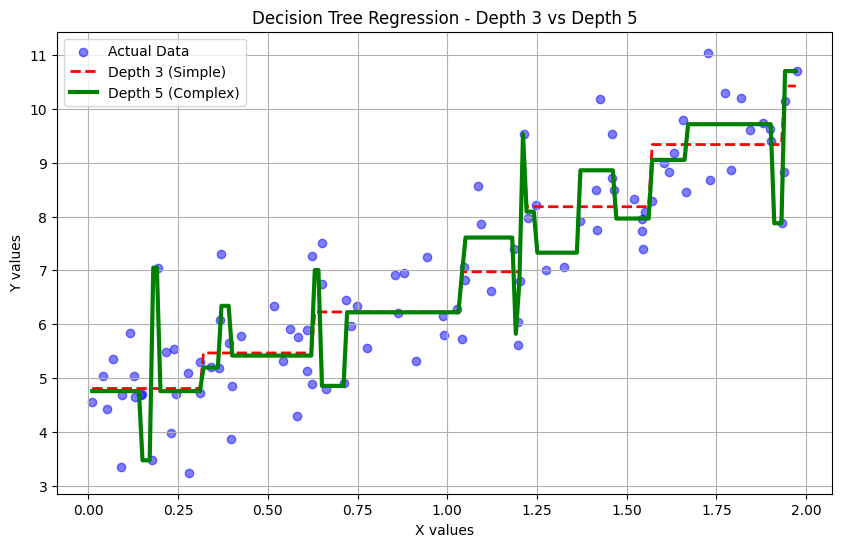

In [18]:
# 1. Naya tree banate hain jisme depth 5 rakhenge
tree_depth_5 = build_tree(x_train, y_train, 0, 5)

# 2. Naye tree se predictions nikalte hain (x_plot pehle se bana hua hai)
y_plot_5 = predict(tree_depth_5, x_plot)

# 3. Graph Plotting (Dono lines ek sath)
plt.figure(figsize=(10, 6))

# Original data points (Blue dots)
plt.scatter(x_train, y_train, color='blue', label='Actual Data', alpha=0.5)

# Purani Decision boundary - Depth 3 (Red dashed line)
plt.plot(x_plot, y_plot, color='red', linewidth=2, linestyle='dashed', label='Depth 3 (Simple)')

# Nayi Decision boundary - Depth 5 (Green solid line)
plt.plot(x_plot, y_plot_5, color='green', linewidth=3, label='Depth 5 (Complex)')

plt.title("Decision Tree Regression - Depth 3 vs Depth 5")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.grid(True)
plt.show()

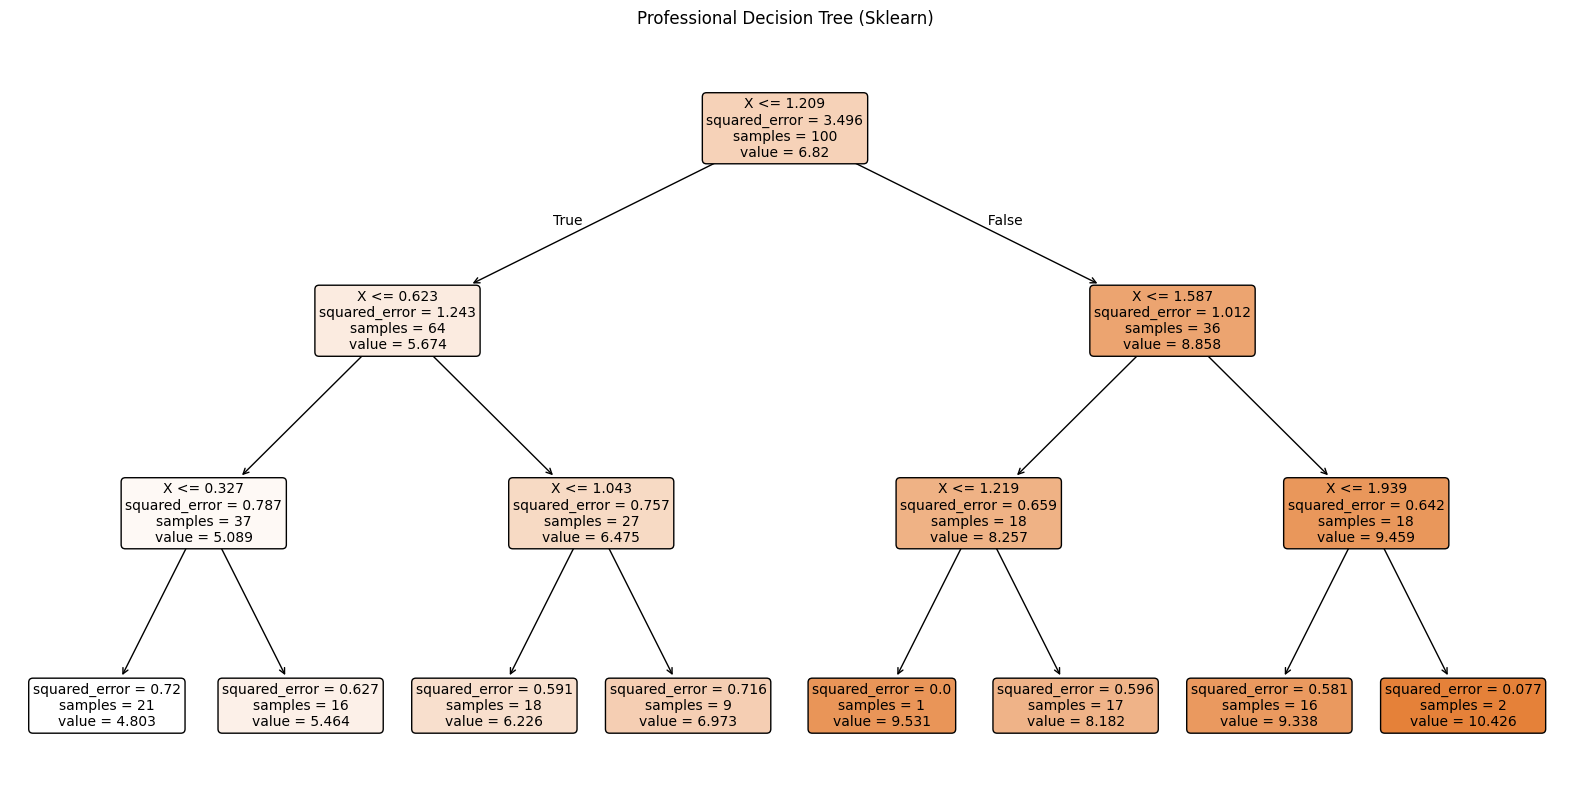

In [19]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 1. Sklearn ka readymade model banate hain (Depth 3 ke sath)
dt_sklearn = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_sklearn.fit(x_train, y_train)

# 2. Asli Graphical Tree plot karte hain!
plt.figure(figsize=(20, 10)) # Size bada rakha hai taaki clear dikhe

# plot_tree function automatically boxes aur arrows bana dega
plot_tree(dt_sklearn, 
          filled=True,             # Boxes mein color bharne ke liye
          feature_names=["X"],     # Feature ka naam
          rounded=True,            # Boxes ke corners gol karne ke liye
          fontsize=10)             # Text ka size

plt.title("Professional Decision Tree (Sklearn)")
plt.show()